<a href="https://colab.research.google.com/github/palarunava/machine-learning-courses/blob/main/tensorflow-developer-professional-certificate/convolution-networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Fashion MNIST Dataset

The [Fashion MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) is a collection of grayscale 28x28 pixel clothing images. Each image is associated with a label as shown in this table.

| Label | Description |
| --- | --- |
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

This dataset is available directly in the [tf.keras.datasets](https://www.tensorflow.org/api_docs/python/tf/keras/datasets) API and you load it like this:

Number of training samples: (60000, 28, 28)
Number of test samples: 10000
Training Sample: 11602
LABEL: 3

IMAGE PIXEL ARRAY:

[[  0   0   0   0   0   0   0   0  13  99 103   2   0   0   0   0  15 105  83   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   1   0   0 225 247 245 255 244 224 222 231 228 229 242 168   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   2   0 122 254 229 232 232 238 242 237 231 219 211 210 195  24   0   4   0   0   0   0   0]
 [  0   0   0   0   0   0   0 222 253 238 241 233 225 221 223 220 220 209 208 198 110   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 228 251 240 235 229 224 225 229 227 214 208 193 196 177   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  29 248 247 241 231 224 220 223 226 233 207 185 210 220 204   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  82 253 244 255 239 227 225 220 220 229 227 209 253 209 174  20   0   0   0   0   0   0]
 [  0   0   0   0   0   0 126 253 225 181 254 228 226 225 218 222 22

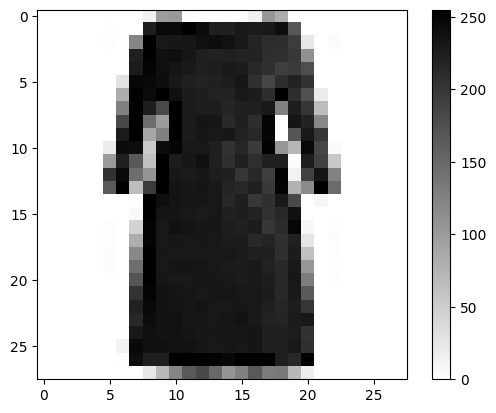

In [5]:
fmnist = tf.keras.datasets.fashion_mnist

# Load the training and test split of the Fashion MNIST dataset
(training_images, training_labels), (test_images, test_labels) = fmnist.load_data()
print(f'Number of training samples: {training_images.shape}')
print(f'Number of test samples: {test_images.shape[0]}')

# You can put between 0 to 59999 here
index = np.random.randint(0, 59999)

# Set number of characters per row when printing
np.set_printoptions(linewidth=320)

# Print the label and image
print(f'Training Sample: {index + 1}')
print(f'LABEL: {training_labels[index]}')
print(f'\nIMAGE PIXEL ARRAY:\n\n{training_images[index]}\n\n')

# Visualize the image using the default colormap (viridis)
# Arg
#   cmp: colormap = 'viridis' by default
plt.imshow(training_images[index], cmap='binary')
plt.colorbar()
plt.show()

# Normalize the pixel values of the train and test images
training_images  = training_images / 255.0
test_images = test_images / 255.0

In [8]:
# Build the classification model
model = tf.keras.models.Sequential([
  tf.keras.Input(shape=(28,28,1)),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),

  # Same output layers
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

# Print the model summary
model.summary()

model.compile(
  optimizer = tf.optimizers.Adam(),
  loss = 'sparse_categorical_crossentropy',
  metrics=['accuracy']
)

history = model.fit(training_images, training_labels, epochs=15)
print(f'History: {history}')

test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f'Test loss: {test_loss}')
print(f'Test accuracy: {test_accuracy}')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,786 (952.29 KB)

 Trainable params: 243,786 (952.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.7722 - loss: 0.6202
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 41ms/step - accuracy: 0.8876 - loss: 0.3090
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9045 - loss: 0.2603
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 41ms/step - accuracy: 0.9192 - loss: 0.2199
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9286 - loss: 0.1906
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 41ms/step - accuracy: 0.9395 - loss: 0.1639
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 40ms/step - accuracy: 0.9437 - loss: 0.1509
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 41ms/step - accuracy: 0.9505 - loss: 0.1305
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 41ms/step - accuracy: 0.9555 - loss: 0.1145
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 41ms/step - accuracy: 0.9628 - loss: 0.0994
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.9671 - loss: 0.0888
Epoch 12